# Beam Sweeping and Probing Along a UE Trajectory

This notebook demonstrates how **NeoRadium** can be used to model beam sweeping and beam probing in a DeepMIMO scenario with a UE moving along a predefined trajectory. It creates a trajectory-based channel, configures CSI-RS resources and CSI reports for sweeping and probing, and visualizes how the selected beam direction evolves as the UE moves through the environment.

The example is intended as an illustrative API demonstration rather than a fully standards-faithful implementation of practical 5G NR beam management. In a real system, beam management procedures, CSI-RS resource design, CSI reporting, triggering, timing relationships, and scheduling are subject to additional 3GPP constraints and implementation-specific details. Here, the workflow is intentionally simplified so the beam sweeping and probing APIs in **NeoRadium** can be demonstrated clearly and compactly.

In [1]:
import numpy as np
import time
import matplotlib
from IPython.display import HTML, Markdown, display

from neoradium import DeepMimoData, TrjChannel, BandwidthPart, AntennaPanel, PDSCH, random
from neoradium import CsiRs, CsiRsSet, CsiRsConfig, CsiReport, CsiReportMan
from neoradium.utils import toDb, toLinear

In [2]:
# Replace this with the folder on your computer where you store DeepMIMO scenarios
dataFolder = "/data/RayTracing/DeepMIMO/Scenarios/V4/"
DeepMimoData.setScenariosPath(dataFolder)

# Create a DeepMimoData object
dmData = DeepMimoData("asu_campus_3p5")
dmData.print()


DeepMimoData Properties:
  Scenario:                   asu_campus_3p5
  Version:                    4.0.0a3
  UE Grid:                    rx_grid
  Grid Size:                  411 x 321
  Base Station:               BS (at [166. 104.  22.])
  Total Grid Points:          131,931
  UE Spacing:                 [1. 1.]
  UE bounds (xyMin, xyMax)    [-225.55 -160.17], [184.45 159.83]
  UE Height:                  1.50
  Carrier Frequency:          3.5 GHz
  Num. paths (Min, Avg, Max): 0, 6.21, 10
  Num. total blockage:        46,774
  LOS percentage:             19.71%




Trajectory Properties:
  start (x,y,z):          (35.45, 89.83, 1.50)
  No. of points:          12,782
  curIdx:                 0 (0.00%)
  curSpeed:               [14.93  0.    0.  ]
  Total distance:         191.37 meters
  Total time:             12.781 seconds
  Average Speed:          14.973 m/s
  Carrier Frequency:      3.5 GHz
  Paths (Min, Avg, Max):  5, 9.09, 10
  Totally blocked:        0
  LOS percentage:         100.00%



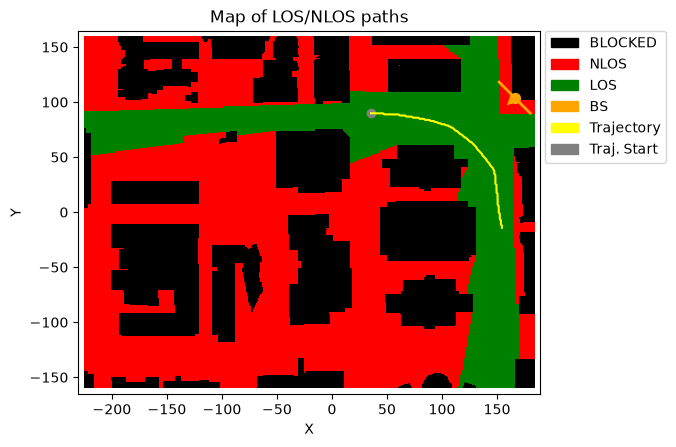

In [3]:
random.setSeed(123)                             # Make results reproducible
txBearingAngle = -135                           # Pointing TX panel to the center of map

bwp = BandwidthPart(numRbs=24, spacing=15)      # Create a bandwidth part

# Create a trajectory passing through the following points
trjPoints = [[35, 90], [57, 89], [76, 86], [91, 83], [107, 78], [118, 70], 
             [128, 62], [139, 49], [147, 38], [149, 22], [151, 2], [154, -14]]
trajectory = dmData.trajectoryFromPoints(trjPoints, bwp, speedMps=15)

trajectory.print()                              # Print the trajectory information
ax = dmData.drawMap("LOS-NLOS", trajectory)     # Draw the map with the trajectory
dmData.drawBsPanel(ax, txBearingAngle)          # Draw the base station antenna panel

In [4]:
def createCsiRS():
    # Create a CSI-RS configuration for beam sweeping and beam probing
    # Beam-sweeping:
    # - 8 beams and 8 CSI-RS objects with resource IDs 1 to 8
    # - CSI-RS resources at symbol 4 and resource elements 2 to 9
    # - One periodic NZP CSI-RS resource set (set ID=1) containing all 8 sweeping resources
    #   with period 20
    # - One periodic CSI report (ID=11) with period 20 and offset=1
    numSweep = 8
    sweepResources = []
    for i in range(numSweep):
        sweepResources += [ CsiRs(resourceId=i+1, numPorts=1, symbols=[4],
                                  freqMap="".join([str(int(x)) for x in np.eye(12)[i+2]])[::-1]) ] # REs 2 to 9
    sweepSet = CsiRsSet("NZP", bwp, resourceType="periodic", rsId=1, period=20, csiRsList=sweepResources)
    sweepReport = CsiReport(sweepSet, reportId=sweepSet.rsId+10, reportType='periodic', 
                            period=20, offset=1, quantity="Cri")        # CSI report for beam sweeping
    
    # Beam-probing:
    # - 4 beams and 4 CSI-RS objects with resource IDs 9 to 12
    # - CSI-RS resources at symbol 4 and resource elements 4 to 7
    # - One aperiodic NZP CSI-RS resource set (set ID=2) containing all 4 probing resources
    #   triggered when sweeping CRI is received.
    # - One aperiodic CSI report (ID=12) triggered when sweeping CRI is received.
    numProbe = 4
    probeResources = []
    for i in range(numProbe):
        probeResources += [ CsiRs(resourceId=i+9, numPorts=1, symbols=[4],
                                  freqMap="".join([str(int(x)) for x in np.eye(12)[i+4]])[::-1]) ] # REs 4 to 7
    probeSet = CsiRsSet("NZP", bwp, resourceType="aperiodic", rsId=2, csiRsList=probeResources)
    probeReport = CsiReport(probeSet, reportId=probeSet.rsId+10, 
                            reportType='aperiodic', quantity="Cri")     # CSI report for beam probing
    
    csiRsConfig = CsiRsConfig([sweepSet, probeSet])             # CSI-RS config
    csiReportMan = CsiReportMan([sweepReport, probeReport])     # CSI report manager
    return csiRsConfig, csiReportMan

def processFeedback(csiReportMan):
    # Process CSI feedback:
    sweepReport, probeReport = csiReportMan.csiReports
    criSweep, criProbe, rsrpProbe = None, None, None

    csiReportInfo = csiReportMan.getFeedback()                  # Get all available CSI reports from CsiReport objects
    for reportId, csiFeedback in csiReportInfo.items():         # Get the CSI feedback for each report
        if reportId == sweepReport.reportId:                    # Sweeping report
            criSweep = csiFeedback.cri.cri                      # CSI-RS resource ID of the best beam
            probeReport.csiRsSets[0].trigger()                  # Trigger Probing CSI-RS resource set
            probeReport.trigger()                               # Trigger Probing report
        
        elif reportId == probeReport.reportId:                  # Probing report
            criProbe = csiFeedback.cri.cri                      # CSI-RS resource ID of the best beam
            rsrpProbe = csiFeedback.cri.rsrp                    # RSRP of the best beam
        else:
            print(f"Unhandled report: {reportId}")

    return criSweep, criProbe, rsrpProbe

In [5]:
random.setSeed(123)                 # Make results reproducible
numSlots = trajectory.numPoints     # Total number of slots = number of points on the trajectory

# Note:
# Since our goal is to show that different UE locations along a trajectory experience different 
# beam RSRPs, we should not normalize the channel gain independently at each location. So, we set 
# the 'normalizeGains' to 'False' in our channel model below and use a fixed noise power.

# Calculating the noise power:
k = 1.380649e-23      # Boltzmann constant (joules per kelvin)
tempK = 290.0         # Temperature in kelvin
nf = 9                # Receiver noise figure (dB)
noiseVarFreq = k*tempK*bwp.spacing*1000*toLinear(nf)

# Creating a trajectory-based channel model:
channel = TrjChannel(bwp, trajectory, 
                     normalizeGains = False,
                     txAntenna = AntennaPanel([1,4], polarization='x'),     # 8 TX antennas
                     txOrientation = [txBearingAngle,0,0],                  # BS antenna orientation
                     rxAntenna = AntennaPanel([1,1], polarization='x',      # 2 RX antennas
                                              beamWidth=[65,360]))          # Omnidirectional

csiRsConfig, csiReportMan = createCsiRS()
# csiRsConfig.print()                                       # Uncomment to print the CSI-RS configuration
# csiReportMan.print()                                      # Uncomment to print the CSI reporting information

# Create a simple PDSCH object for end-to-end transmission
pdsch = PDSCH(bwp, numLayers=1, modulation="16QAM", csiRsConfig=csiRsConfig)
pdsch.setDMRS(additionalPos=1)     # DMRS configuration

ldpc = pdsch.getLdpcCodec(coderates=490/1024)

minMse, maxMse = 100, 0
t0 = time.monotonic()
print(f"\nSimulating communication over {numSlots} slots along the trajectory ...")
print(" Slot    Blk Errors    BLER    Beam Ang   RSRP (dB)   Trj. Time   Exe. Time")
print("------   ----------   ------   --------   ---------   ---------   ---------")

txBlockErrors = 0
sweepWs, sweepBeams = channel.txAntenna.getSweepingBeams(numTheta=1, numPhi=8)
curSweepCri, curProbeCri, curProbeRsrp = None, None, None
probePhiLocal, probePhiGlobal = None, None
channel.restart()
blefs = np.zeros(numSlots, dtype=np.int8)                   # Block error flags for each slot
beamAngles = np.zeros((numSlots,2), dtype=np.float32)       # Beam angles for each slot (theta, phi)
beamRsrps = np.zeros(numSlots, dtype=np.float32)            # Beam RSRPs
for slotNo in range(numSlots):
    
    criSweep, criProbe, rsrpProbe = processFeedback(csiReportMan)      # Process CSI feedback
    if criSweep is not None:    curSweepCri = criSweep      # Update current Sweeping CRI 
    if criProbe is not None:
        curProbeCri = criProbe                              # Update current Probing CRI
        curProbeRsrp = rsrpProbe                            # Update current Probing RSRP
        probePhiLocal = probeBeams[1][criProbe-9]
        _, probePhiGlobal = AntennaPanel.local2Global( probeBeams[0][criProbe-9],
                                                       probePhiLocal,
                                                       channel.txOrientation)
        
    pdsch.initGrid()                                        # Initialize PDSCH's internal resource grid 
    numBits = pdsch.getBitCapacity()[0]                     # Capacity of the resource grid for PDSCH data
    txBlock = random.bits(ldpc.txBlockSizes[0])             # Create a random transport block
    
    rateMatchedCodeBlocks = ldpc.encode(txBlock, numBits)   # LDPC rate-matching and encoding
    pdsch.setPdschData(rateMatchedCodeBlocks)               # Populates the PDSCH's internal grid. 
    
    channelMatrix = channel.getChannelMatrix()              # Get the channel matrix
    precoder = pdsch.getPrecodingMatrix(channelMatrix)      # Get the precoder matrix from PDSCH object

    txGrid = bwp.createGrid(len(channel.txAntenna))         # Create the transmitted resource grid
    pdsch.precodeTo(txGrid, precoder)                       # Perform the precoding and put data in `txGrid`

    # Process CSI-RS:
    csiRsResources = csiRsConfig.getResources()             # Get all CSI-RS resources for the current slot, if any
    for csiSetId, setResources in csiRsResources.items():
        if csiSetId == 1:                                               # Beam Sweeping:
            for resourceId, (lIdx, kIdx, sweepReValues) in setResources.items():
                b = resourceId-1                                        # Sweeping resource ID to beam index
                w = sweepWs[:,b:b+1]                                    # Sweeping vector (nt x 1)
                txGrid[:,lIdx, kIdx] = (w @ sweepReValues,              # Update txGrid with precoded CSI-RS values
                                        "CSIRS_NZP",                    # Set RE's type to NZP CSI-RS
                                        resourceId)                     # Set RE's object ID to CSI-RS resource ID
        
        elif csiSetId == 2:                                             # Beam probing:
            b = curSweepCri-1                                           # Beam index of current sweeping CRI 
            theta0, phi0 = sweepBeams[0][b], sweepBeams[1][b]           # Best beam angles derived from Sweeping CRI
            probeWs, probeBeams = channel.txAntenna.getProbingBeams(theta0, phi0, 4, polStrategy='equal')
            for resourceId, (lIdx, kIdx, probeReValues) in setResources.items():
                b = resourceId - 9                                      # Probing resource ID to beam index
                w = probeWs[:,b:b+1]                                    # Precoding vector for this beam. nt x 1
                txGrid[:,lIdx, kIdx] = (w @ probeReValues,              # Update txGrid with precoded CSI-RS values
                                        "CSIRS_NZP",                    # Set RE's type to NZP CSI-RS
                                        resourceId)                     # Set RE's object ID to CSI-RS resource ID

    rxGrid = txGrid.applyChannel(channelMatrix)                         # Apply the channel in frequency domain
    noisyRxGrid = rxGrid.addNoise(noiseVar=noiseVarFreq)                # Add noise

    csiReportMan.processRxGrid(noisyRxGrid, csiRsResources)             # UE-side processing of the received CSI-RS

    effChanMat = channel.getEffChannel(channelMatrix, precoder)         # Get effective channel matrix
    eqGrid, llrScales = pdsch.equalize(noisyRxGrid, effChanMat)         # Equalize the received grid
    llrs = pdsch.getLLRs(eqGrid, llrScales)                             # Demodulate and get LLRs
    decodedTxBlocks, crcMatch = ldpc.decode(llrs)                       # LDCP rate-recovery and decoding
    txBlockErrors += 0 if crcMatch[0][0] else 1                         # crcMatch[0][0] -> CRC match for txBlock

    blefs[slotNo] = 0 if crcMatch[0][0] else 1                          # Block error flag for this slot
    beamAngles[slotNo] = np.nan if probePhiGlobal is None else probePhiGlobal # Current beam angles based on probing CRI
    beamRsrps[slotNo] = np.nan if curProbeRsrp is None else curProbeRsrp
    dt = time.monotonic()-t0                                            # Total time spent so far
    
    print(f"\r{slotNo+1:^6,d}   {txBlockErrors:^10,d}   {100*txBlockErrors/(slotNo+1):^6.2f}   " 
          f"{"N/A" if probePhiLocal is None else str(np.round(probePhiLocal,2)):^8s}   "
          f"{"N/A" if curProbeRsrp is None else str(np.round(curProbeRsrp,2)):^9s}   "
          f"{channel.trajectory.cur.time:^9.2f}   {dt:^9.2f}", end='')
    channel.goNext()                                                    # Move to the next slot and trajectory point



Simulating communication over 12782 slots along the trajectory ...
 Slot    Blk Errors    BLER    Beam Ang   RSRP (dB)   Trj. Time   Exe. Time
------   ----------   ------   --------   ---------   ---------   ---------
12,782       0         0.00     38.21      -55.59       12.78      1560.99 

In [6]:
arrow, prevRsrp = None, None

# Since we are averaging the angles, we need to make sure they are continuous:
# Local angle range: -90 to 90
# Global angle range: 135 .. -45
# Adjusted global angle range: 135 .. 315  (Add 360 to the negative values)
beamAngles = np.array(beamAngles)
beamAngles[beamAngles<0] += 360     # Range: 135 .. 315

# Callback used to initialize and update the scenario map and the graphs below it
def handleGraph(request, ax, trajectory, points=None):
    global arrow, prevRsrp
    if request=="Config":
        ax[0].set_xlim(0,trajectory.numPoints)
        ax[0].set_ylim(-65,-50)
        ax[0].set_title("RSRP of the Best Beam (dB)")
        ax[0].set_xlabel("Trajectory Points")
        ax[0].grid()

    elif request=="ConfigMap":
        ax.set_title("Beam Tracking Along a UE Trajectory Using CSI Feedback")
        dmData.drawBsPanel(ax, txBearingAngle)   # Draw TX antenna panel

        # Create the arrow patch
        arrow = dmData.drawBeamArrow(ax, txBearingAngle, color="cyan", length=50)
        arrow.set_animated(True)

    elif request=="Draw":
        # Draw the RSRP plot below the map
        p0, p1 = points
        segmentRsrps = beamRsrps[p0:p1]
        meanRsrp = segmentRsrps[~np.isnan(segmentRsrps)].mean()
        if prevRsrp is None:    prevRsrp = meanRsrp
        ax[0].plot([p0,p1], [prevRsrp,  meanRsrp], 'blue', markersize=1)
        prevRsrp = meanRsrp
    
    elif request=="DrawOnMap":
        p0, p1 = points
        segmentAngles = beamAngles[p0:p1]
        meanPhi = segmentAngles[~np.isnan(segmentAngles)].mean()
        # Now that we have computed the mean angle, we can remove the 360 to get 
        # the angle back in the correct range
        if meanPhi>180: meanPhi -= 360
        # Update the arrow direction
        dmData.drawBeamArrow(ax, meanPhi, color="cyan", length=50, arrow=arrow)
        return (arrow,)

# Create the animation and display it below
anim = dmData.animateTrajectory(trajectory, numGraphs=1, pointsPerFrame=200, 
                                graphCallback=handleGraph, fileName='AnimateCRI.gif',
                                lastFrameDur=3000)  # Freeze on last frame for 3 seconds
display(Markdown("![demo](AnimateCRI.gif)"))

# Alternatively, the following code provides better control over running 
# the animation. Note that for this method to work, you should not pass a 
# 'fileName' to the 'animateTrajectory' function.
#    # Increase the animation memory limit for HTML-based animation display
#    matplotlib.rcParams['animation.embed_limit'] = 100000000
#    anim = dmData.animateTrajectory(trajectory, numGraphs=1, pointsPerFrame=200, 
#                                    graphCallback=handleGraph)
#    HTML(anim.to_jshtml())

![demo](AnimateCRI.gif)